# Exploration of CLIP flaws

Multimodal model can have unexpected biases. CLIP, for example, is strongly biased toward text in the text. A great example can be found [here](https://arxiv.org/pdf/2508.05430#page=8.94), Figure 6, where CLIP "sees" a doll, but is actually focused on "dollar" text, not an actual doll. Is thid a **real** problem? Considering that most of the content on web is watermarked in some way, this might be an issue. During today's lab, we will try to reproduce this phenomena on ImageNet creating artifically injected watermarks.

The coding agenda is as follow:

1. load a CLIP and stream ImageNet dataset
2. create a custom version of dataset with injected watermarks
3. iterate over dataset, compute metrics on original and injected data
4. compute simple CAV (diff means)
5. debias representation of injected data and compare metric to the original data

In [1]:
import os
from pathlib import Path
from typing import Any, Literal

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont, Image as PILImage
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from tqdm import tqdm
from datasets import load_dataset
from huggingface_hub import login

import torch
from torch.utils.data import DataLoader, Dataset, IterableDataset, Subset
from transformers import CLIPModel, CLIPProcessor

### 00 Prelimaries

code below serves as utilty to inject watermarks. You need to pass `image` and `text` to be injected, the rest of parameters can be left as default. The watermark transformation can be used via 

```python
torchvision.transforms.Compose([partial(add_watermark, ...), clip_text_preprocessor])
```

I've modified the add_watermark function to add centered, high-visibility text.

In [2]:
_IMAGE_SIZE_TO_FONT_SIZE = {
    224: 36,
    384: 62,
    512: 82,
    518: 84,
}
_FONT_SIZE_RATIO = 6.22 

def create_add_watermark_function(text: str = 'TEXT'):
    def add_watermark(
        image: np.ndarray | PILImage.Image,
        image_size: int = 224,
        text: str = text,
        font_path: str = "./assets/fonts/SourceHanSerifSC-Bold.otf",
        opacity: float = 0.8, # Zwiększone dla lepszej widoczności
        color: tuple[int, int, int] = (255, 255, 255),
        x_pos: float = 0.5,
        y_pos: float = 0.5,
    ) -> PILImage.Image:
        
        # 1. INTELIGENTNE ŁADOWANIE CZCIONKI
        font_size = _IMAGE_SIZE_TO_FONT_SIZE.get(image_size, int(image_size / _FONT_SIZE_RATIO))
        
        try:
            if os.path.exists(font_path):
                font = ImageFont.truetype(font_path, font_size)
            else:
                # Jeśli Twoja ścieżka nie działa, szukamy czegokolwiek co nie jest 'load_default'
                fallback_fonts = ["arial.ttf", "DejaVuSans-Bold.ttf", "LiberationSans-Bold.ttf", "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf"]
                font = None
                for f in fallback_fonts:
                    try:
                        font = ImageFont.truetype(f, font_size)
                        break
                    except: continue
                if font is None: font = ImageFont.load_default()
        except:
            font = ImageFont.load_default()

        if isinstance(image, np.ndarray):
            # Ważne: upewnij się, że obraz to uint8 0-255 przed konwersją
            if image.max() <= 1.01: image = (image * 255).astype(np.uint8)
            image = PILImage.fromarray(image.astype(np.uint8), 'RGB')

        image_rgba = image.convert("RGBA")
        width, height = image_rgba.size
        draw = ImageDraw.Draw(image_rgba)

        # 2. DYNAMICZNE SKALOWANIE ROZMIARU (Żeby nie ucinało)
        # Próbujemy dopasować czcionkę, żeby zajmowała max 85% szerokości
        target_width = 0.85 * width
        
        # Sprawdzamy rozmiar dla obecnej czcionki (o ile to nie load_default)
        if not isinstance(font, ImageFont.ImageFont): # load_default jest innego typu
            for _ in range(10): # Max 10 prób zmniejszenia
                bbox = draw.textbbox((0, 0), text, font=font)
                curr_w = bbox[2] - bbox[0]
                if curr_w > target_width:
                    font_size = int(font_size * 0.9)
                    font = ImageFont.truetype(font.path, font_size)
                else:
                    break

        # 3. RYSOWANIE WARSTWY
        watermark_layer = PILImage.new("RGBA", image_rgba.size, (0, 0, 0, 0))
        draw_wm = ImageDraw.Draw(watermark_layer)

        draw_wm.text(
            xy=(x_pos * width, y_pos * height),
            text=text,
            fill=(*color, round(opacity * 255)),
            font=font,   # FIX: tutaj było 30, teraz jest wyliczony font!
            anchor="mm", 
            stroke_width=max(1, font_size // 20), # Proporcjonalny obrys
            stroke_fill=(0, 0, 0, round(opacity * 255))
        )

        return PILImage.alpha_composite(image_rgba, watermark_layer).convert("RGB")

    return add_watermark

### 01 CLIP and Imagenet loading

You should already know how to load CLIP from previous labs. For ImageNet, you need to find it on HuggingFace. You can check for `imagenet-1k` for smaller volume. Note that "mini" version is still too bug to make the full experiment, so feel free to constraint experiments to 100-200 images. Use `streaming=True`, so the datasrt is not donwloaded on your PC/notebook, but is streamed from web. It is much slower, but fits our needs best.

Side note: `test` split of ImageNet does not have labels.

#### Loading Clip

In [3]:
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

#### Loading dataset

In [6]:
token = ""

In [5]:
login(token=token)

In [7]:
dataset = load_dataset(
    "imagenet-1k", 
    split="validation", 
    streaming=True, 
    trust_remote_code=True
)

subset = dataset.take(200)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'imagenet-1k' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

### 02 Custom dataset

Because of `streaming=True`, you already have `IterableDatset` object. It already has `__getitem__` implemented, so we need to add our custom logic in `__iter__`. The logic should be as follows:

```python
    def __iter__(self):
        for example in self.dataset:
            <your code here>
            yield img, img_corrupted, label
```

Remember that `yield` should return `Tensor`, `dict[str, Tensor]`, or so. Ensure that your custom dataset returns (original image after CLIP processing, image after watermark injection and CLIP processing, original label).

Tip: datasets typically returns index of a class, not its label (e.g., `1`, not `goldfish`). You can still find label using `dataset.features["label"].int2str(IDX)`.

Tip 2: because of streaming, the biggest bottleneck is HuggingFace API, consider setting `batch_size` on `64` or more.

In [8]:
class MyIterableDatatset(IterableDataset):
    def __init__(self, streaming_dataset, processor, watermark_fn=None):
        self.dataset = streaming_dataset
        self.processor = processor
        self.watermark_fn = watermark_fn 

    def __iter__(self):
        for example in self.dataset:
            image = example['image']
            label = example['label']

            corrupted_image = image.copy()

            if self.watermark_fn is not None:
                corrupted_image = self.watermark_fn(corrupted_image)

            with torch.no_grad():
                inputs_orig = self.processor(images=image, return_tensors="pt")
                img_tensor = inputs_orig['pixel_values'].squeeze(0)
    
                inputs_corr = self.processor(images=corrupted_image, return_tensors="pt")
                img_corrupted_tensor = inputs_corr['pixel_values'].squeeze(0)

            yield img_tensor, img_corrupted_tensor, label

### 03 Metrics computation

So far, you should have loaded CLIP and iterable dataset. Now it's time to creating **interesting** experiment. The design is up to you, but let's check my proposal below:

> - set watermark text to something like "BLUEBERRY"
> - use CLIP in zero-shot mode (comparing embedding of text and image)
> - check how many images will be predicted as "BLUEBERRY" rather than the original class
>   - e.g., compare cossim(image_watermark, "a photo of a BLUEBERRY") and cossim(image_watermark, "a photo of [ORIGINAL CLASS]")

After this step, you should tell the accuracy of the CLIP in distinguishing between BLUEBERRY and [ORIGINAL CLASS] on original data and data with watermarks (or analogous metrics in our own experiment design).

Tip: use `padding=True` when processing text in batches.

Note: I proposed BLUEBERRY for no particural reason, but keep in mind tht ImageNet contains ~all types of images so to be completly fair in this experiment we should choose something that does not occur in this dataset probably.

In [9]:
my_dataset = MyIterableDatatset(
    streaming_dataset=dataset,
    processor=processor,
    watermark_fn=create_add_watermark_function('BLUEBERRY')
)

In [10]:
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

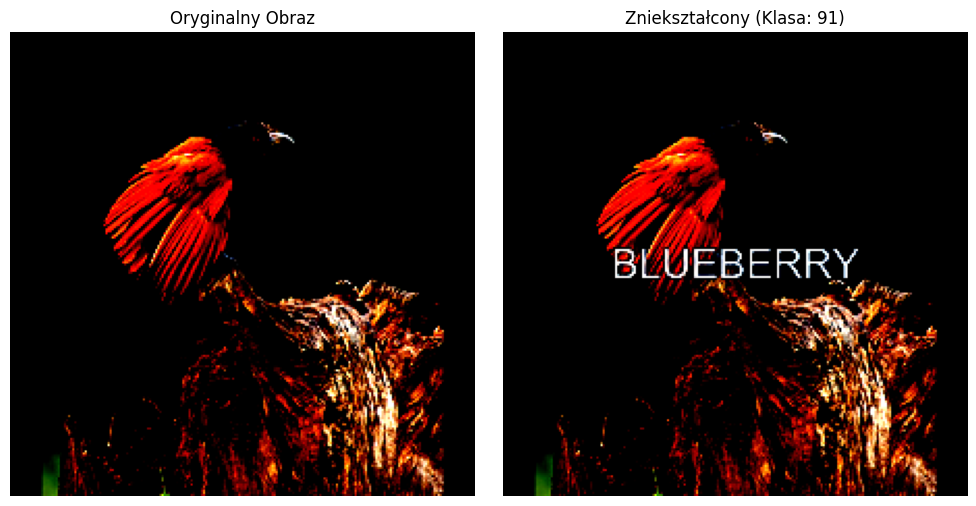

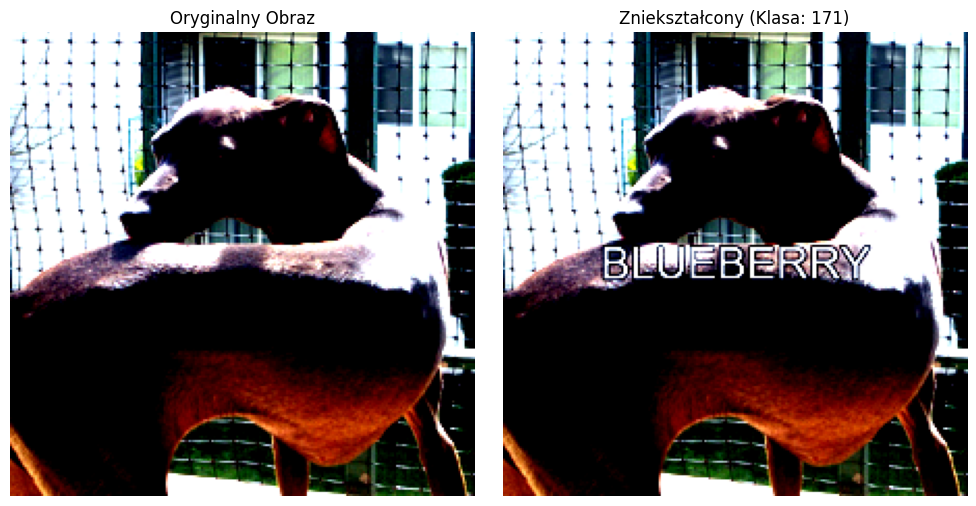

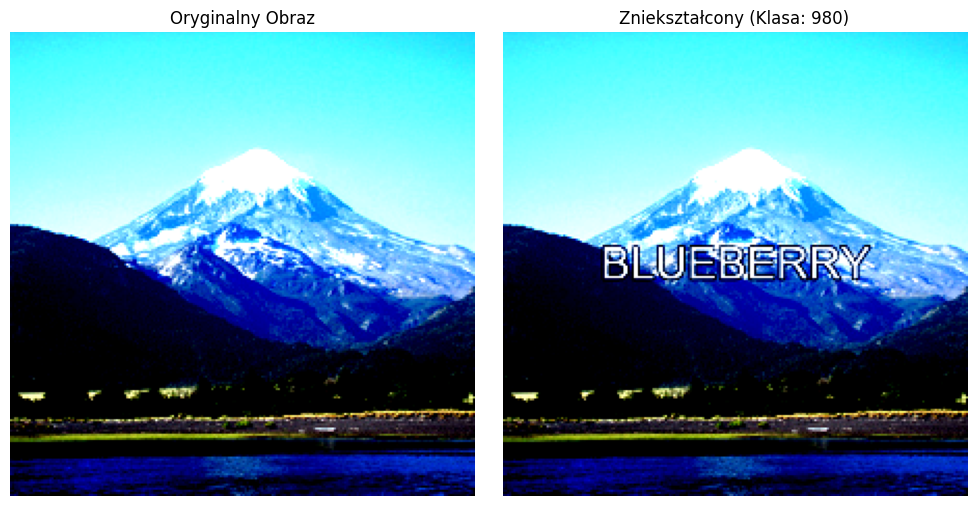

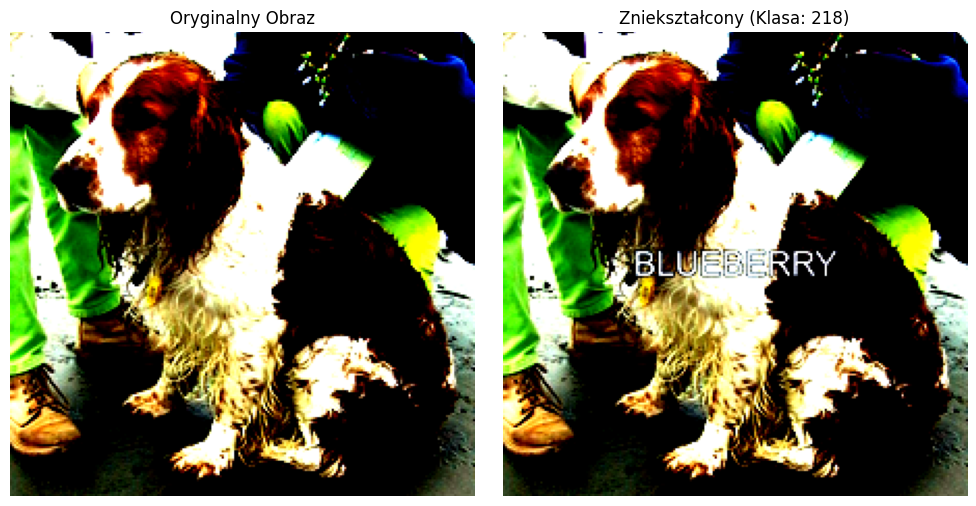

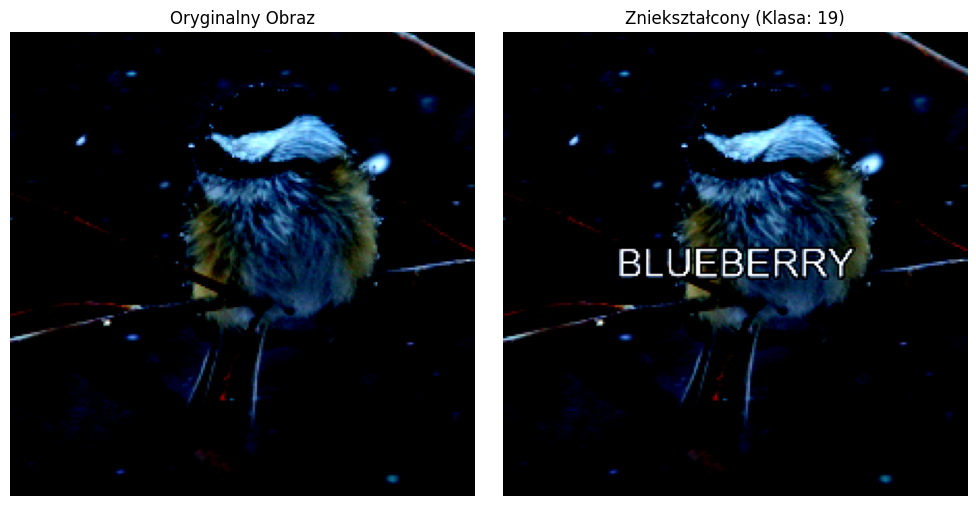

In [11]:
index = 0

for image, image_corr, _ in my_dataset:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Konwersja z formatu Torch (CHW) na format Matplotlib (HWC)
    # Jeśli obrazy są w formie Tensorów, używamy .permute()
    img_plot = image.permute(1, 2, 0).cpu().numpy()
    corr_plot = image_corr.permute(1, 2, 0).cpu().numpy()

    # Wyświetlanie oryginału
    axes[0].imshow(img_plot)
    axes[0].set_title("Oryginalny Obraz")
    axes[0].axis('off') # Ukrywamy osie dla estetyki
    
    # Wyświetlanie zniekształconego (z watermarkiem)
    axes[1].imshow(corr_plot)
    axes[1].set_title(f"Zniekształcony (Klasa: {_})")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show

    index += 1

    if index == 5:
        break

In [12]:
my_dataset = MyIterableDatatset(
    streaming_dataset=dataset,
    processor=processor,
    watermark_fn=create_add_watermark_function('BLUEBERRY')
)

In [13]:
model.eval() # Tryb ewaluacji
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
None

In [14]:
imagenet_class_names = dataset.features["label"].names

In [15]:
target_label = 'BLUEBERRY'

correct = corrupted = total = 0

data_loader = DataLoader(my_dataset, batch_size=128)

for img_orig, img_corr, label_indices in data_loader:

    total += img_orig.shape[0]

    labels = [imagenet_class_names[index] for index in label_indices]
    all_prompts = [[f"photo of {label}", 'photo of ' + target_label] for label in labels]
    result = []

    for prompts in all_prompts:
        result += prompts
    

    with torch.no_grad():
        text_inputs = processor(text=result, return_tensors="pt", padding=True).to(device)
        text_features = model.get_text_features(**text_inputs)

        img_features_orig = model.get_image_features(pixel_values=img_orig)
        img_features_corr = model.get_image_features(pixel_values=img_corr)

        img_features_orig /= img_features_orig.norm(dim=-1, keepdim=True)
        img_features_corr /= img_features_corr.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        for i in range(img_orig.shape[0]):
            current_text_features = text_features[2*i : 2*i + 2]
            
            logits_orig = img_features_orig[i] @ current_text_features.T
            if logits_orig.argmax() == 0:
                correct += 1

            logits_corr = img_features_corr[i] @ current_text_features.T
            if logits_corr.argmax() == 1:
                corrupted += 1
        
    break

In [16]:
print(f'Total picutes: {total}')
print(f'Original images correctly classified : {correct}')
print(f'Images coruppted with text incorrectly classified: {corrupted}')

Total picutes: 128
Original images correctly classified : 127
Images coruppted with text incorrectly classified: 90


aż 29 ze 128 obrazków z napisami zostało źle zaklasyfikowanych

### 04 CAV computation

In this step, you should create a CAV (e.g., DiffMeans we used in previous work) and check its detection power - i.e., `rocauc(cossim(CAV, data))`. This should be really easy!

In [17]:
from sklearn.metrics import roc_auc_score


model.eval()

all_features_orig = []
all_features_corr = []
with torch.no_grad():
    for img_orig, img_corr, _ in data_loader:
        features_orig = model.get_image_features(img_orig.to(device))
        features_corr = model.get_image_features(img_corr.to(device))
        
        features_orig /= features_orig.norm(dim=-1, keepdim=True)
        features_corr /= features_corr.norm(dim=-1, keepdim=True)
        
        all_features_orig.append(features_orig.cpu())
        all_features_corr.append(features_corr.cpu())

        break

features_orig = torch.cat(all_features_orig, dim=0)
features_corr = torch.cat(all_features_corr, dim=0)

In [18]:
features_orig.shape, features_corr.shape

(torch.Size([128, 512]), torch.Size([128, 512]))

In [19]:
mean_orig = features_orig.mean(dim=0)
mean_corr = features_corr.mean(dim=0)
cav = mean_corr - mean_orig
cav /= cav.norm()

In [20]:
cosine_similarity_orig = (features_orig @ cav).numpy() # cosine_similarity, bo wektory w wierszach macierzy
cosine_similarity_corr = (features_corr @ cav).numpy() # i wektor cav są znormalizowane

In [21]:
y_true = np.concatenate([np.zeros(len(cosine_similarity_orig)), np.ones(len(cosine_similarity_corr))])
y_scores = np.concatenate([cosine_similarity_orig, cosine_similarity_corr])

print(f'ROC-AUC : {roc_auc_score(y_true, y_scores):.3f}')

ROC-AUC : 0.993


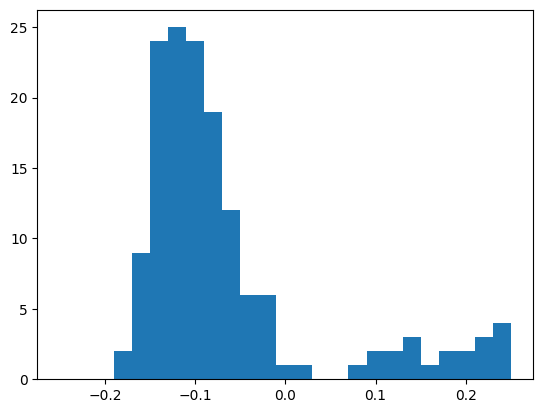

In [22]:
plt.hist(y_scores, bins=np.arange(-0.25, 0.26, 0.02))
plt.show()

### 05 Debiasing

Now we have everything we need to make CLIP robust to watermarks. In this step, repeat the logic from **03**, but make an ortogonalisation of data with injected watermark. Ideally, its CLIP's embedding should be similar to the original data (you can check!); however, our main goal is to just improve the accuracy of zero-shot classification.

In [23]:
cav.shape

torch.Size([512])

In [24]:
my_dataset = MyIterableDatatset(
    streaming_dataset=dataset,
    processor=processor,
    watermark_fn=create_add_watermark_function('BLUEBERRY')
)

In [25]:
def orthogonalize(features, cav):
    dot_product = (features @ cav.T)

    return features - dot_product.unsqueeze(1) @ cav.unsqueeze(0)

In [28]:
target_label = 'BLUEBERRY'

correct = corrupted = total = 0

data_loader = DataLoader(my_dataset, batch_size=128)
distances = []

for img_orig, img_corr, label_indices in data_loader:

    total += img_orig.shape[0]

    labels = [imagenet_class_names[index] for index in label_indices]
    all_prompts = [[f"photo of {label}", 'photo of ' + target_label] for label in labels]
    result = []

    for prompts in all_prompts:
        result += prompts
    

    with torch.no_grad():
        text_inputs = processor(text=result, return_tensors="pt", padding=True).to(device)
        text_features = model.get_text_features(**text_inputs)

        img_features_orig = model.get_image_features(pixel_values=img_orig)
        img_features_corr = model.get_image_features(pixel_values=img_corr)

        print()

        ## ortogonalizacja
        img_features_orig = orthogonalize(img_features_orig, cav=cav)
        img_features_corr = orthogonalize(img_features_corr, cav=cav)

        distances.append((img_features_orig - img_features_corr).norm(dim=1))

        ## normalizacja
        img_features_orig /= img_features_orig.norm(dim=-1, keepdim=True)
        img_features_corr /= img_features_corr.norm(dim=-1, keepdim=True)

        

        text_features /= text_features.norm(dim=-1, keepdim=True)

        for i in range(img_orig.shape[0]):
            current_text_features = text_features[2*i : 2*i + 2]
            
            logits_orig = img_features_orig[i] @ current_text_features.T
            if logits_orig.argmax() == 0:
                correct += 1

            logits_corr = img_features_corr[i] @ current_text_features.T
            if logits_corr.argmax() == 1:
                corrupted += 1
        
    break

print(f'Total picutes: {total}')
print(f'Original images correctly classified after orthogonaliztion: {correct}')
print(f'Images coruppted with text incorrectly classified after orthogonaliztion: {corrupted}')


Total picutes: 128
Original images correctly classified after orthogonaliztion: 126
Images coruppted with text incorrectly classified after orthogonaliztion: 9


#### Wnioski
Wcześniej na 128 obrazków z napisami 90 zostało błędnie przypisanych do napisu. Po ortogonalizacji względem wektora tylko 9 na 128 został błędnie zaklasyfikowany, co oznacza sukces. Dodatkowo spadła nam również liczb poprawnie zaklasyfikowanych obrazków bez napisu.

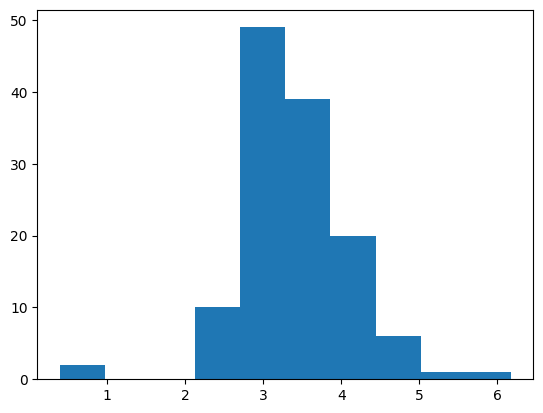

In [27]:
plt.hist(distances[0])
plt.show()

Normy różnic nie są takie duże jak na wektor w przestrzeni 512 wymiarowej.